# (27) poisson + BALLS64: (32, 128.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 64
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = int(npix * 1.5)

cfg_vae['t_train'] = 32
cfg_vae['beta_outer'] = 96.0

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  397.5 K   |
|     ———     |    ———     |
|    layer    |  397.5 K   |
+-------------+------------+

poisson_BALLS64_t-32_b-96_k-[96]_u-10,du-10
b200-ep600-lr(0.0005)_temp(0.01:0.5)_gr(5000)_(2025_04_27,10:57)

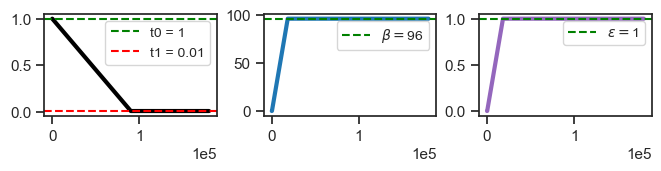

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [5]:
tr.n_iters

180000

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=4096, latent_dim=96, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [8]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 600, avg loss: -493.447: 100%|██████| 600/600 [7:00:20<00:00, 42.03s/it]


In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0057], device='cuda:0', grad_fn=<ExpBackward0>),)

In [12]:
print(tr.model.layer.n_exp)

tensor([186, 218, 242, 270, 296, 320, 346, 366, 381, 395, 405, 412, 418, 422,
        426, 428, 429, 434, 433, 435, 437, 438, 437, 440, 443, 440, 443, 445,
        444, 445, 447, 447], device='cuda:0', dtype=torch.int32)

In [27]:
u_max = np.array(tr.model.stats['u_max']).squeeze()
du_max = np.array(tr.model.stats['du_max']).squeeze()

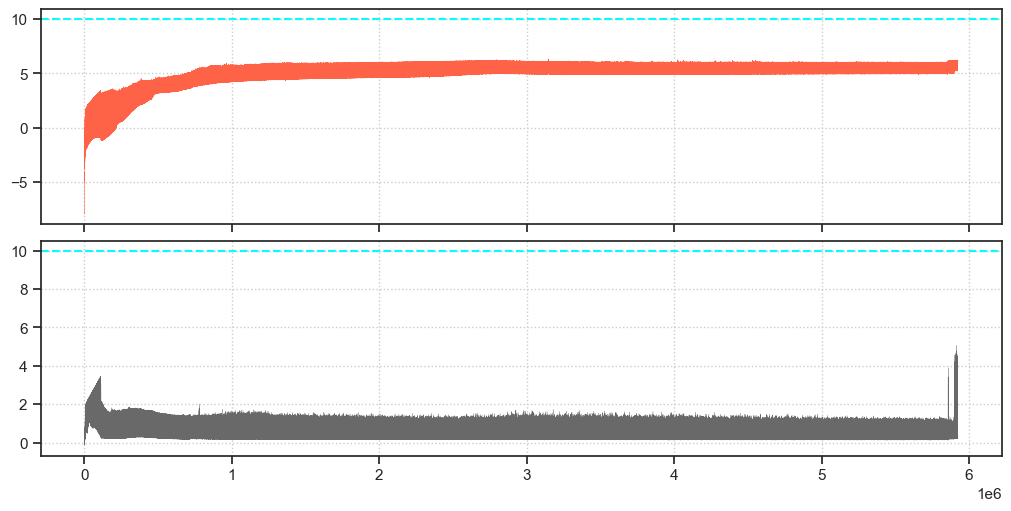

In [28]:
fig, axes = create_figure(2, 1, (10, 5), sharex='all')
axes[0].plot(u_max, lw=0.2, label='u_max', color='tomato')
axes[1].plot(du_max, lw=0.2, label='du_max', color='dimgrey')
axes[0].axhline(tr.model.cfg.clamp_u, color='cyan', ls='--')
axes[1].axhline(tr.model.cfg.clamp_du, color='cyan', ls='--')
add_grid(axes)
plt.show()

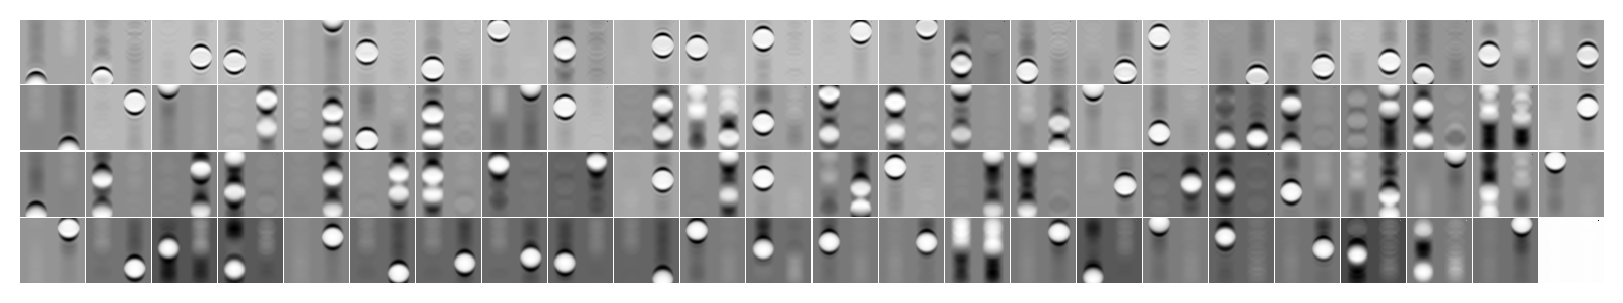

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=4);

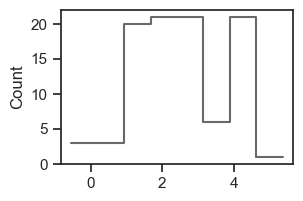

In [14]:
histplot(u0, color='dimgrey')
plt.show()

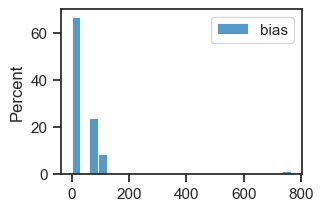

In [15]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

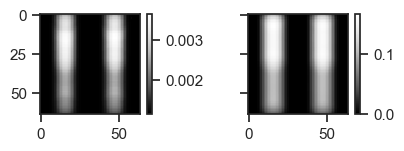

In [16]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(npix, npix)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.20s/it]


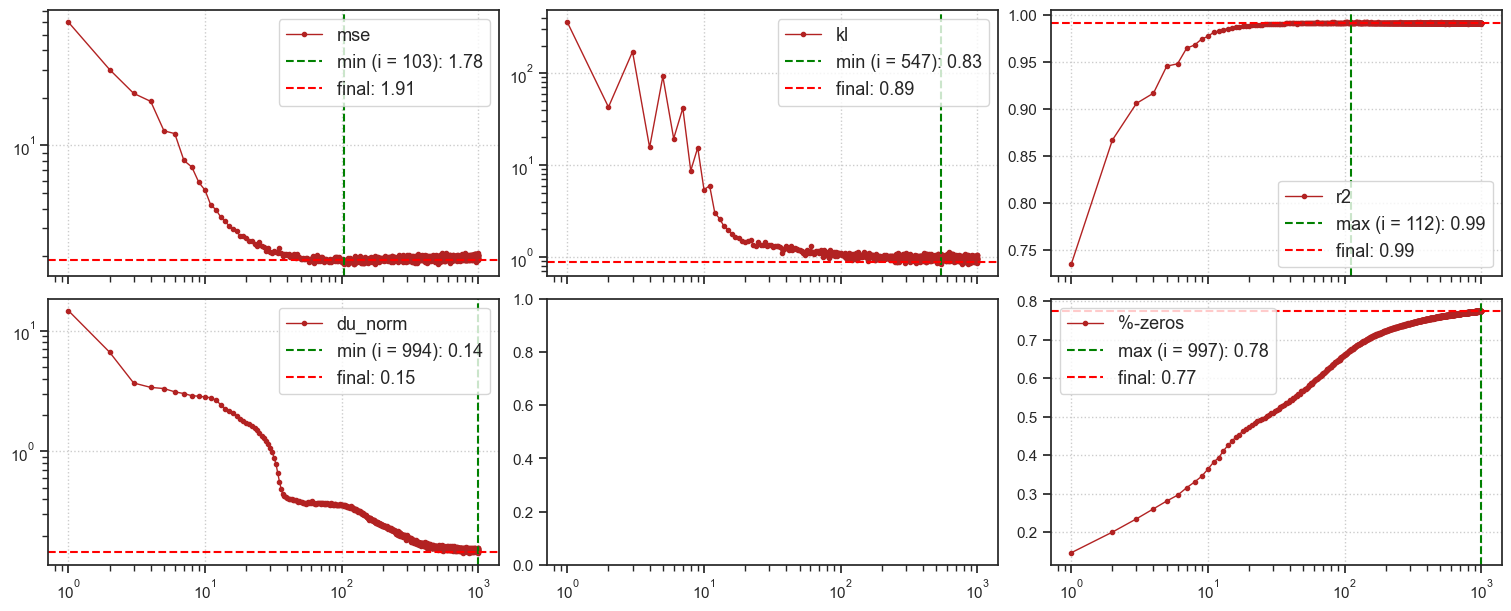

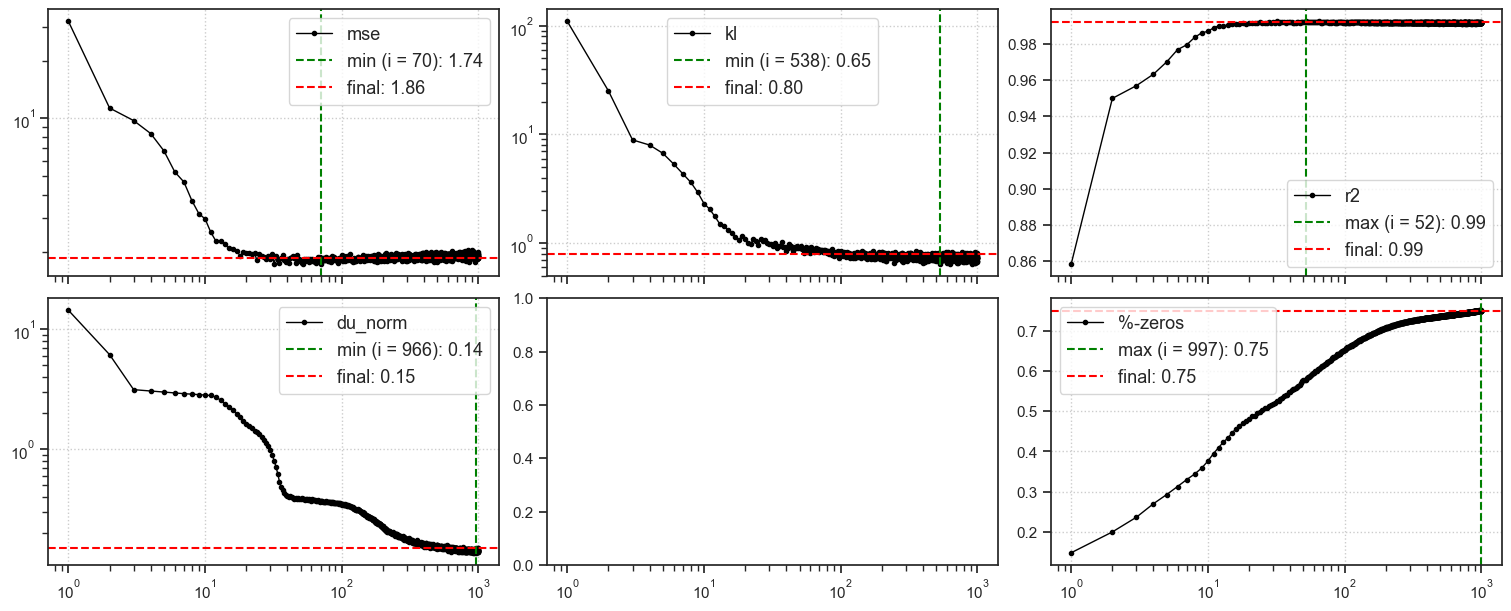

CPU times: user 11.8 s, sys: 63.5 ms, total: 11.9 s
Wall time: 11.9 s


In [18]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=2,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [21]:
from analysis.linear import untangle_score

output = untangle_score(tr, t_total=1000, save_freq=50)

100%|█████████████████████████████████| 25/25 [01:45<00:00,  4.22s/it]


In [22]:
print(f"r2 tst:", output['r2_zg']['tst'])

r2 tst:
{
    1: array([-2.3654666, -0.5433706], dtype=float32),
    50: array([0.92923135, 0.9579885 ], dtype=float32),
    100: array([0.9297898, 0.9595548], dtype=float32),
    150: array([0.9245452 , 0.96449816], dtype=float32),
    200: array([-1.9903305,  0.9650852], dtype=float32),
    250: array([0.87953484, 0.9833073 ], dtype=float32),
    300: array([0.95813686, 0.9860172 ], dtype=float32),
    350: array([0.9673295 , 0.99004215], dtype=float32),
    400: array([0.97184294, 0.99112934], dtype=float32),
    450: array([0.9714662, 0.9915779], dtype=float32),
    500: array([0.9760075, 0.9918308], dtype=float32),
    550: array([0.9779643 , 0.99210775], dtype=float32),
    600: array([0.97845566, 0.99153566], dtype=float32),
    650: array([0.97773784, 0.9917349 ], dtype=float32),
    700: array([0.97985464, 0.99170864], dtype=float32),
    750: array([0.98027164, 0.9920267 ], dtype=float32),
    800: array([0.98019737, 0.9914298 ], dtype=float32),
    850: array([0.98035187, 0.9918603 ], dtype=float32),
    900: array([0.98188376, 0.9913223 ], dtype=float32),
    950: array([0.98232436, 0.9912755 ], dtype=float32),
    1000: array([0.98238325, 0.99204654], dtype=float32)
}

r2 tst:
{
    1: array([-1.6319821 ,  0.72672826], dtype=float32),
    100: array([0.9737534, 0.9901319], dtype=float32),
    200: array([0.98411494, 0.9894894 ], dtype=float32),
    300: array([0.98571974, 0.98771966], dtype=float32),
    400: array([0.98594934, 0.9876326 ], dtype=float32),
    500: array([0.98411584, 0.9878618 ], dtype=float32),
    600: array([0.9840913 , 0.98761535], dtype=float32),
    700: array([0.98281133, 0.9870516 ], dtype=float32),
    800: array([0.98209316, 0.9878183 ], dtype=float32),
    900: array([0.9832502, 0.9880444], dtype=float32),
    1000: array([0.984105 , 0.9883092], dtype=float32)
}